# House Prices

## 1. Problem Definition

We are going to predict the sales price for each house. This is a regression problem because we need to predict continuous numerical values.

We are going to find the Root-Mean-Squared-Log-Error (RMSLE) between the logaritghm of the predicted value and the logarithm of the observed sales price.

## 2. Data

All the data we need we can find it [here](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data). The data has been split into:
  * `train.csv` - the training set
  * `test.csv` - the test dataset

The train database contains 81 columns and 1460 rows. It cointains 79 features. In the download data it is possible to find `data_description.txt` where we can find the description of all these features.

## 3. Evaluation

The goal of this project is to find the sale price for each house. For each Id in the test set, we must need to predict the value of the `SalePrice` variable.

The submissions for this problem are evaluated on Root-Mean-Squared-Log-Error(RMSLE) betwwen the logarithm of the predicted value and the logarithm of the observed sale prices. Using RMSLE we are going to treat the errors in price in cheap house the same way if the house is more expensive.

## 4. Preparing the tools

We are going first the libaries that we think we are going to need for this project, but as we go we are going to import more of these libraries.

After finishing the project we can consolidate all these libraries in the top of the notebook.

Also, we will need to give access to our notebook to the necessary credentials (Kaggle_key) that we need for our work.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
from google.colab import userdata

# Retrieve credentials
KAGGLE_KEY =  userdata.get('KAGGLE_KEY')
KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')

import os
os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY'] = KAGGLE_KEY

## 5. Load the data

Get the data from the Kaggle competition website

In [3]:
#!pip install -q kaggle

In [4]:
#!kaggle competitions download -c house-prices-advanced-regression-techniques
#!unzip house-prices-advanced-regression-techniques.zip

In [5]:
from google.colab import files
uploaded = files.upload()  # opens a file picker
!unzip house-prices-advanced-regression-techniques.zip

Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques.zip
Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


## 6. Inspect the data

In [6]:
import pandas as pd

test_df = pd.read_csv('test.csv')
train_df = pd.read_csv('train.csv')

test_ids = test_df["Id"].copy()

In [7]:
# Check train_df
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

Let's check for what data is missing in each category

In [10]:
train_df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


## 7. Data visualization

Plot the target variable (`SalesPrice`) to understand it.

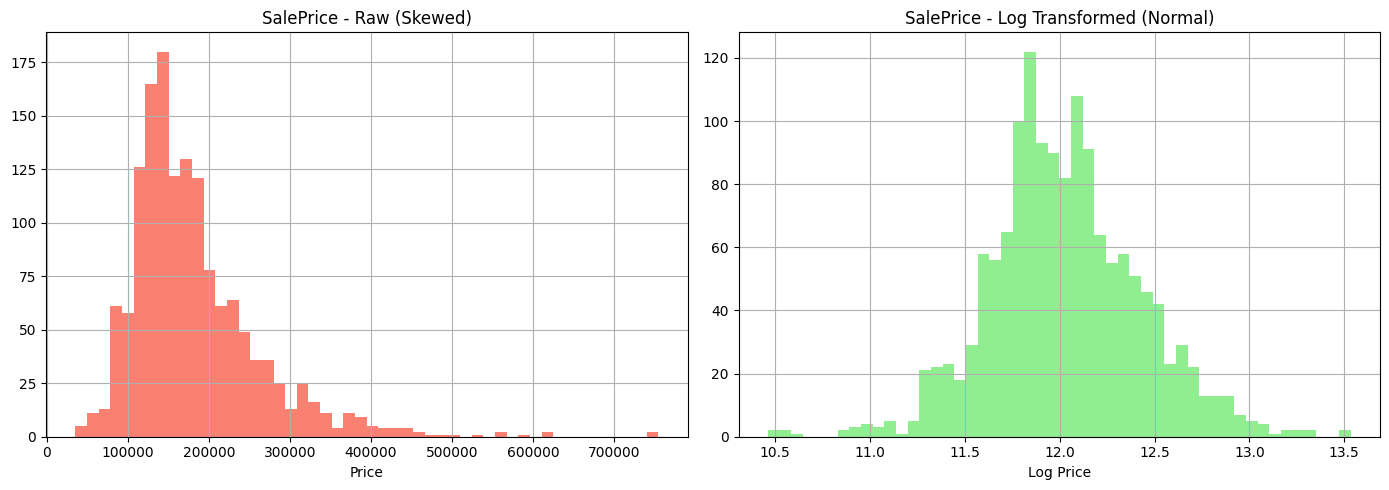

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

train_df["SalePrice"].hist(bins=50, ax=ax1, color="salmon")
ax1.set_title("SalePrice - Raw (Skewed)")
ax1.set_xlabel("Price")

# Let's transform raw prices into a symmetric distribution
np.log1p(train_df["SalePrice"]).hist(bins=50, ax=ax2, color="lightgreen")
ax2.set_title("SalePrice - Log Transformed (Normal)")
ax2.set_xlabel("Log Price")

plt.tight_layout()
plt.show()

Let's understand these two plots:
 * *First plot*: SalePrice Raw: in this plot we can see that the majority of the houses are in the 100,000-200,000 dollars range. We can find a tail that strechs toward 500,000+ dollars. There a few very expensive houses but those are rare.

 * *Second plot*: SalePrice Log: in this plot we can see the application of `np.log1p()` to every price before training. This way the distances between values become more proportional so it is better to use with ML algorithms.

Let's plot a correlation matrix for the numerical feature. This we'll tell us which features have the strongest linear relationshiph with `SalePrice`.

Anything above 0.5 or below -0.5 is worth paying attention to. Anythig above 0.7 is a strong signal.

In [12]:
correlation = train_df.select_dtypes(include=[np.number]).corr()
top_corr = correlation["SalePrice"].sort_values(ascending=False)
print(top_corr.head(15))  # top 15 positively correlated
print(top_corr.tail(5))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


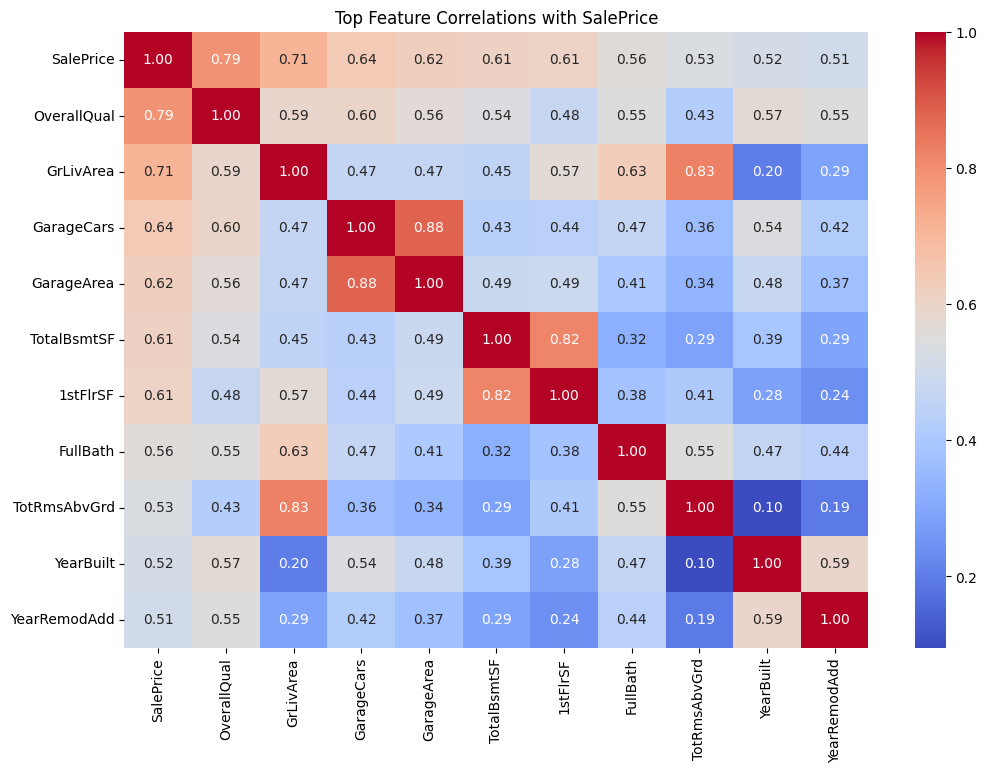

In [13]:
top_features = top_corr.head(11).index  # top 10 + SalePrice itself

plt.figure(figsize=(12, 8))
sns.heatmap(
    train_df[top_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Top Feature Correlations with SalePrice")
plt.show()

In this case we case that the features with a better correlation (above 0.7) are `OverallQual` and `GrLivArea`.

Other features to pay attention (above 0.5) are `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlSF`, `FullBath`, `TotRmAbvGrd`, `YearBuilt` and `YearRemoAdd`

Now, let's identify the categorical features.

In [14]:
categorical_cols = train_df.select_dtypes(include=["object"]).columns.tolist()
print(f"Number of categorical features: {len(categorical_cols)}")
print(f"Categorical features: {categorical_cols}")

Number of categorical features: 43
Categorical features: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


Let's plot what could be the most important that could affect the price

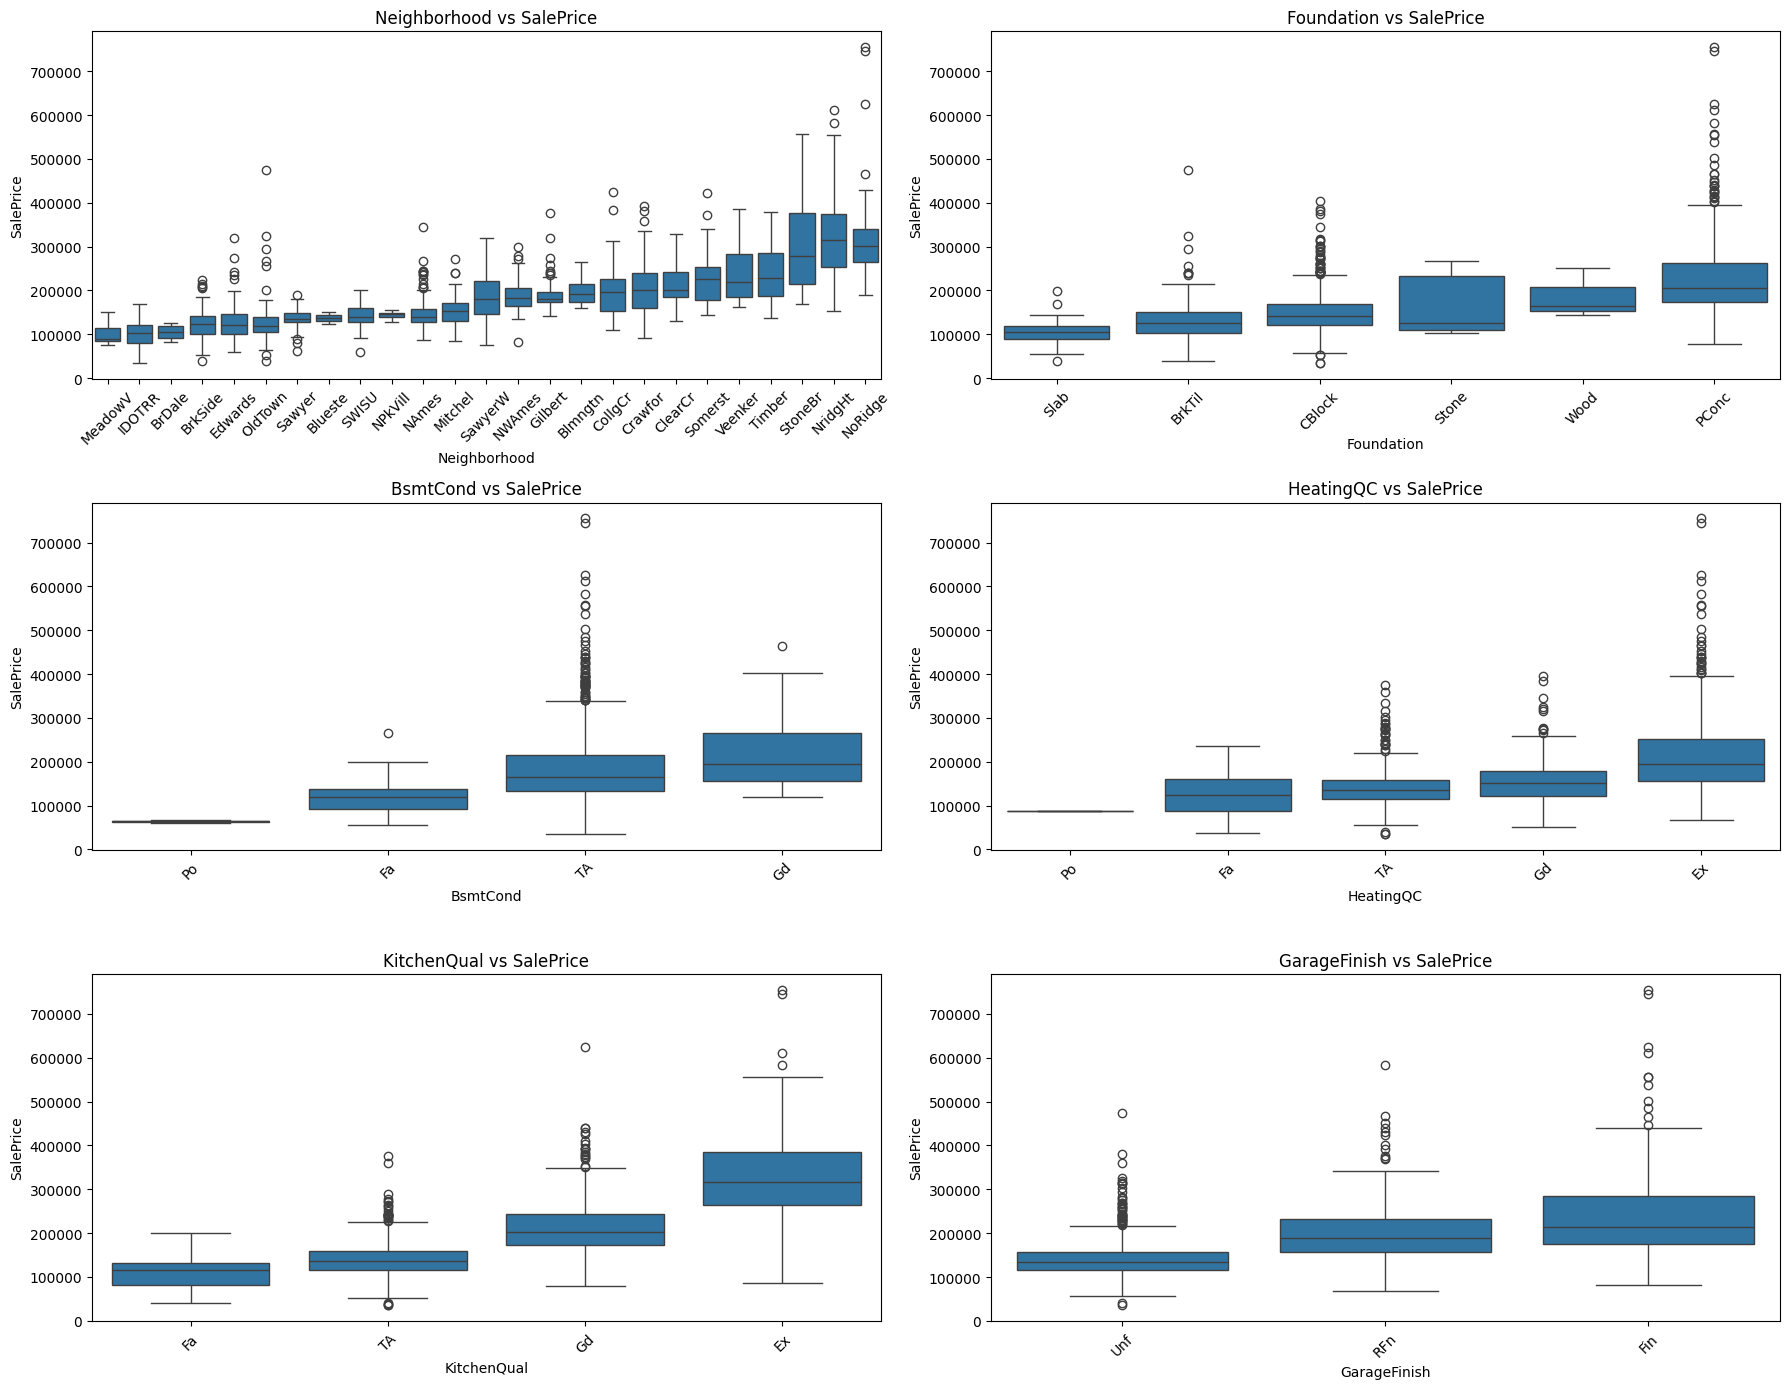

In [15]:
important_cat = [ "Neighborhood", "Foundation", "BsmtCond",
                 "HeatingQC", "KitchenQual","GarageFinish"]

fig,axes = plt.subplots(3,2, figsize=(18,14))
axes = axes.flatten()

for i, col in enumerate(important_cat):
  order = train_df.groupby(col)["SalePrice"].mean().sort_values().index
  ax = sns.boxplot(x=col, y="SalePrice", data=train_df, order=order, ax=axes[i])
  axes[i].set_title(f"{col} vs SalePrice")
  axes[i].tick_params(axis="x", rotation = 45)

plt.tight_layout()
plt.show()

Let's explain and understand these plots:
 * *Neighborhood vs SalePrice*: we can see that the boxes are dramatically different accros the differen neigborhoods. For example, `MeadowV` on the far left has a median aroun 100k dollars, meanwhile `NoRidge` or `NridgHt` have medians around 300k+ dollars.
 * *Foundation vs SalePrice*: we can se clear differences like `Slab` foundations have the lowest prices, meanwhile `PConc` has the hightest median.
 * *BsmtCond vs SalePrice*: `Po`(poor) is clearly the lowest and `Gd` (good) is higher as it can be expected.
 * *HeatingQC vs SalePrice*: big price difference between the heating queality, showing `Po`(poor) at the bottom and `Ex` (excellent) at the top. Higher prices when better quality
 * *KitchenQual vs SalePrice*:  `Fa` (fair) around 110k dollars median, `TA` (typical) around 160k dollars, `Gd` (good) around 210k dollars, `Ex` (excellent) around 315k dollars. Nearly linear relationship between kitchen quality and price.
 * *GarageFinish vs SalePrice*: `Unf` (unfinished) has the lowest median around 140k dollars, `RFn` (rough finished) in the middle around 200k dollars, `Fin` (finished) highest around 230k dollars. We can assume that a finished garage is a premium feature.

## 8. Prepare the data

Now it is time to handle the missing values and encode the non-numerical columns into numbers.

Let's start seeing how many missing values we have in each category. For this project, most missing categorical values mean that the feature doesn't exist for that house. So we are going to fill those values with `"None"`.

In [16]:
missing = train_df[categorical_cols].isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
GarageFinish      81
GarageQual        81
GarageType        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtFinType1      37
BsmtCond          37
Electrical         1
dtype: int64


In [17]:
missing = test_df[categorical_cols].isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

PoolQC          1456
MiscFeature     1408
Alley           1352
Fence           1169
MasVnrType       894
FireplaceQu      730
GarageFinish      78
GarageQual        78
GarageCond        78
GarageType        76
BsmtCond          45
BsmtExposure      44
BsmtQual          44
BsmtFinType1      42
BsmtFinType2      42
MSZoning           4
Utilities          2
Functional         2
Exterior2nd        1
Exterior1st        1
KitchenQual        1
SaleType           1
dtype: int64


In [18]:
# These missing values mean the house doesn't HAVE that feature
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageFinish", "GarageQual", "GarageType", "GarageCond",
             "BsmtExposure", "BsmtFinType2", "BsmtQual", "BsmtFinType1",
             "BsmtCond", "MasVnrType"]

for col in none_cols:
    train_df[col] = train_df[col].fillna("None")
    test_df[col] = test_df[col].fillna("None")

# These are genuinely missing - fill with mode from train
mode_cols = ["Electrical", "MSZoning", "Functional",
             "Exterior1st", "Exterior2nd", "KitchenQual", "SaleType"]

for col in mode_cols:
    mode_val = train_df[col].mode()[0]
    train_df[col] = train_df[col].fillna(mode_val)
    test_df[col] = test_df[col].fillna(mode_val)

Now let's work with the numerical features

In [19]:
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
missing_num = train_df[numerical_cols].isnull().sum()
print(missing_num[missing_num > 0].sort_values(ascending=False))

LotFrontage    259
GarageYrBlt     81
MasVnrArea       8
dtype: int64


In [20]:
numerical_cols = test_df.select_dtypes(include=[np.number]).columns.tolist()
missing_num = test_df[numerical_cols].isnull().sum()
print(missing_num[missing_num > 0].sort_values(ascending=False))

LotFrontage     227
GarageYrBlt      78
MasVnrArea       15
BsmtHalfBath      2
BsmtFullBath      2
BsmtFinSF1        1
BsmtFinSF2        1
TotalBsmtSF       1
BsmtUnfSF         1
GarageCars        1
GarageArea        1
dtype: int64


Let's work with each different value separated.

`LotFrontage` is the linear feet of street connected to property. It is missing from 259 houses, we have to assume that it's geniunely missing data because we are going to assume that all the houses have street conection. We are going to use the median from the other houses in the same neigborhood to fill these missing values.


In [21]:
lot_median = train_df.groupby("Neighborhood")["LotFrontage"].median()

train_df["LotFrontage"] = train_df.apply(
    lambda row: lot_median[row["Neighborhood"]]
    if np.isnan(row["LotFrontage"]) else row["LotFrontage"], axis=1
)

test_df["LotFrontage"] = test_df.apply(
    lambda row: lot_median[row["Neighborhood"]]
    if np.isnan(row["LotFrontage"]) else row["LotFrontage"], axis=1
)


With `GarageYrBlt` we know those values are missing because there are 81 houses with no garage from the categorical values. So no garage means no year built. Let's fill it with 0

In [22]:
train_df["GarageYrBlt"] = train_df["GarageYrBlt"].fillna(0)
test_df["GarageYrBlt"] = test_df["GarageYrBlt"].fillna(0)

With `MasVnrArea` same thing, we have already filled `MasVnrType` with "None" because they don't have it. So we are going to fill this with 0 too.

In [23]:
train_df["MasVnrArea"] = train_df["MasVnrArea"].fillna(0)
test_df["MasVnrArea"] = test_df["MasVnrArea"].fillna(0)

With the rest of values that are still missing from the test dataset, we are going to fill those with 0.

In [24]:
zero_col_test = ["BsmtHalfBath", "BsmtFullBath", "BsmtFinSF1", "BsmtFinSF2",
                 "TotalBsmtSF", "BsmtUnfSF", "GarageCars", "GarageArea"]

for col in zero_col_test:
    test_df[col] = test_df[col].fillna(0)

In [25]:
# Check if we have any value still missing
print("Train missing:", train_df.isnull().sum().sum())
print("Test missing:", test_df.isnull().sum().sum())

Train missing: 0
Test missing: 2


Before encoding anything, let's create new features to help us out. We are going to create new features:
 * `TotalSF`: total square footgage - combines basment + first floor + second floor
 * `HouseAge`: how old the house was when it was sold.
 * `YearsSinceRemodeled`: how many years has past since the last remodel of the house when it was sold.
 * `TotalBath`: total bathrooms - combines all bathrooms types to get the total bathrooms of the house
 * `HasPool`: explicity saying if there is a pool
 * `HasFirePlace`: explicity saying if there is a fireplace
 * `HasGarage`:explcity saying if there is garage.
 * `TotalPorchSF`: combine in one feature all porche-realated features.
 * `TotalBuiltArea`: it combines all the build areas together (Living area + basement + garage)

In [26]:
# Total square footage - combines basement + first floor + second floor
train_df["TotalSF"] = train_df["TotalBsmtSF"] + train_df["1stFlrSF"] + train_df["2ndFlrSF"]
test_df["TotalSF"] = test_df["TotalBsmtSF"] + test_df["1stFlrSF"] + test_df["2ndFlrSF"]

# How old was the house when it was sold
train_df["HouseAge"] = train_df["YrSold"] - train_df["YearBuilt"]
test_df["HouseAge"] = test_df["YrSold"] - test_df["YearBuilt"]

# Years since last remodel at time of sale
train_df["YearsSinceRemodel"] = train_df["YrSold"] - train_df["YearRemodAdd"]
test_df["YearsSinceRemodel"] = test_df["YrSold"] - test_df["YearRemodAdd"]

In [27]:
# Total bathrooms - combines all bathroom types
train_df["TotalBath"] = (train_df["FullBath"] + train_df["BsmtFullBath"] +
                          0.5 * train_df["HalfBath"] + 0.5 * train_df["BsmtHalfBath"])
test_df["TotalBath"] = (test_df["FullBath"] + test_df["BsmtFullBath"] +
                         0.5 * test_df["HalfBath"] + 0.5 * test_df["BsmtHalfBath"])

# Has pool, has fireplace, has garage as explicit binary flags
train_df["HasPool"] = (train_df["PoolArea"] > 0).astype(int)
test_df["HasPool"] = (test_df["PoolArea"] > 0).astype(int)

train_df["HasFireplace"] = (train_df["Fireplaces"] > 0).astype(int)
test_df["HasFireplace"] = (test_df["Fireplaces"] > 0).astype(int)

train_df["HasGarage"] = (train_df["GarageArea"] > 0).astype(int)
test_df["HasGarage"] = (test_df["GarageArea"] > 0).astype(int)

In [28]:
# Total Porch features all in one
train_df["TotalPorchSF"] = (train_df["WoodDeckSF"] + train_df["OpenPorchSF"] +
                             train_df["EnclosedPorch"] + train_df["ScreenPorch"])
test_df["TotalPorchSF"] = (test_df["WoodDeckSF"] + test_df["OpenPorchSF"] +
                            test_df["EnclosedPorch"] + test_df["ScreenPorch"])

# Combines all major area features
train_df["TotalBuiltArea"] = train_df["GrLivArea"] + train_df["TotalBsmtSF"] + train_df["GarageArea"]
test_df["TotalBuiltArea"] = test_df["GrLivArea"] + test_df["TotalBsmtSF"] + test_df["GarageArea"]

So quality columns like `KitchenQual`, `BsmtQual`, `HeatingQC` have a natural order: Po < Fa < TA< Gd< Ex. To keep this order we are going to use OrdinalEnconder.

In [29]:
from sklearn.preprocessing import OrdinalEncoder

quality_cols = ["KitchenQual", "BsmtQual", "BsmtCond",
                "FireplaceQu", "HeatingQC", "ExterQual",
                "PoolQC"]

quality_order = ["None", "Po", "Fa", "TA", "Gd", "Ex"]

for col in quality_cols:
    if col in train_df.columns:
        train_df[col] = pd.Categorical(train_df[col], categories=quality_order, ordered=True).codes
        test_df[col] = pd.Categorical(test_df[col], categories=quality_order, ordered=True).codes

`MSSubClass` is actually a categorical feature disguised as number. It represents the type of dwelling. The numbers don't have a mathematical meaning. We are going to convert it to a string before continuing.

In [30]:
train_df["MSSubClass"] = train_df["MSSubClass"].astype(str)
test_df["MSSubClass"] = test_df["MSSubClass"].astype(str)

For now we are only going to drop `Utilites` since we saw that it is essentially a constant and `Id` since it is just a row number.

In [31]:
columns_drop = ["Street", "Alley", "LandContour", "Condition2",
               "RoofMatl", "Heating", "MiscFeature", "ExterCond",
               "BsmtFinType2", "GarageQual", "GarageCond", "Fence",
               "PoolQC", "Functional", "LandSlope", "LowQualFinSF",
               "PoolArea", "MiscVal", "BsmtFinSF2", "3SsnPorch",
               "MoSold", "YrSold", "Utilities", "Id"]


train_df = train_df.drop(columns= columns_drop)
test_df = test_df.drop(columns=columns_drop)

Why we don't drop more features right now?

Because we don't know how the features interact with each other. A feature that looks weak on its own might actually contribute more when combined with other features inside a model.

The features that are useless will reveal themselves later after running our first model.


In [32]:
train_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LotConfig,Neighborhood,Condition1,BldgType,HouseStyle,...,SalePrice,TotalSF,HouseAge,YearsSinceRemodel,TotalBath,HasPool,HasFireplace,HasGarage,TotalPorchSF,TotalBuiltArea
0,60,RL,65.0,8450,Reg,Inside,CollgCr,Norm,1Fam,2Story,...,208500,2566,5,5,3.5,0,0,1,61,3114
1,20,RL,80.0,9600,Reg,FR2,Veenker,Feedr,1Fam,1Story,...,181500,2524,31,31,2.5,0,1,1,298,2984
2,60,RL,68.0,11250,IR1,Inside,CollgCr,Norm,1Fam,2Story,...,223500,2706,7,6,3.5,0,1,1,42,3314
3,70,RL,60.0,9550,IR1,Corner,Crawfor,Norm,1Fam,2Story,...,140000,2473,91,36,2.0,0,1,1,307,3115
4,60,RL,84.0,14260,IR1,FR2,NoRidge,Norm,1Fam,2Story,...,250000,3343,8,8,3.5,0,1,1,276,4179


Instead of encoding everythin at once, we are going to concatenate first and encode later. This way we guarantee that both dataframes have the exactly the same columns.

In [33]:
# Make a copy of SalePrice for later and log-transform it (really importan in regression problems)
y = np.log1p(train_df["SalePrice"])
n_train = len(train_df)

# Concat train (without SalePrice column) and test together
combined = pd.concat([train_df.drop(columns=["SalePrice"]), test_df], axis = 0, sort = False)

# One-hot encode everything at once
combined = pd.get_dummies(combined, drop_first= True)

# split the combined dataframe into train/test
train_enc = combined.iloc[:n_train].copy()
test_enc = combined.iloc[n_train:].copy()

# Reattach the SalesPrice column transformed
train_enc["SalePrice"] = y.values

## 9. Split the data

In [34]:
# Create X and y
X_full = train_enc.drop(columns=["SalePrice"])
y_full = train_enc["SalePrice"]

X_test_for_submission = test_enc.copy()

In [35]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

After splitting the data we need to scale the numerical columns

In [36]:
from sklearn.preprocessing import StandardScaler

# Detect continuous numerical columns FIRST before scaling
all_numerical = X_train.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in all_numerical if X_train[col].nunique() > 2]
print(f"Columns to scale: {len(numerical_cols)}")

# Scale X_train/val - fit ONLY on X_train
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])

# Scale X_full for GridSearch - fit on X_full
scaler_full = StandardScaler()
X_full_scaled = X_full.copy()
X_full_scaled[numerical_cols] = scaler_full.fit_transform(X_full[numerical_cols])

# Scale test set ONCE using scaler_full
X_test_for_submission[numerical_cols] = scaler_full.transform(X_test_for_submission[numerical_cols])

Columns to scale: 40


## 10. Start Modelling

In [37]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

models = {
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

In [38]:
from sklearn.model_selection import cross_val_score
import numpy as np

for name, model in models.items():
    scores = cross_val_score(
        model, X_full_scaled, y_full,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    rmse_scores = np.sqrt(-scores)  # convert back to positive RMSE
    print(f"{name}: {rmse_scores.mean():.4f} (+/- {rmse_scores.std():.4f})")

Ridge: 0.3758 (+/- 0.0281)
Random Forest: 0.3712 (+/- 0.0137)
Gradient Boosting: 0.3523 (+/- 0.0102)
XGBoost: 0.3691 (+/- 0.0111)


In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

# Gradient Boosting
gb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "min_samples_leaf": [1, 2, 4]
}

gb_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
gb_gs.fit(X_full_scaled, y_full)
print("Best GB params:", gb_gs.best_params_)
print("Best GB RMSE:", np.sqrt(-gb_gs.best_score_))

# XGBoost
xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_gs = GridSearchCV(
    XGBRegressor(random_state=42),
    xgb_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
xgb_gs.fit(X_full_scaled, y_full)
print("Best XGB params:", xgb_gs.best_params_)
print("Best XGB RMSE:", np.sqrt(-xgb_gs.best_score_))


from lightgbm import LGBMRegressor

lgbm_params = {
    "n_estimators": [300, 500],
    "max_depth": [-1],          # -1 means no limit, let num_leaves control it
    "learning_rate": [0.01, 0.05],
    "num_leaves": [31, 63, 127],
    "min_child_samples": [10, 20, 30],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

lgbm_gs = GridSearchCV(
    LGBMRegressor(random_state=42),
    lgbm_params,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)
lgbm_gs.fit(X_full_scaled, y_full)
print("Best LGBM params:", lgbm_gs.best_params_)
print("Best LGBM RMSE:", np.sqrt(-lgbm_gs.best_score_))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best GB params: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 300}
Best GB RMSE: 0.35066695429693556
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best XGB params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}
Best XGB RMSE: 0.34965461601671916
Fitting 5 folds for each of 144 candidates, totalling 720 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000928 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4167
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 159
[LightGBM] [Info] Start training from score 12.024057
Best LGBM params: {'colsample_bytree

In [40]:
# Build final model with winning params
final_model = XGBRegressor(
    **xgb_gs.best_params_,
    random_state=42
)

# Fit on all training data
final_model.fit(X_full_scaled, y_full)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

## 11. Make Predictions

In [41]:
# Predict and reverse log transform
final_preds = np.expm1(final_model.predict(X_test_for_submission))

submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": final_preds
})

submission.to_csv("submission.csv", index=False)
print("Done. Go submit it.")


Done. Go submit it.
